# 02. Model Training & Comparison

Notebook này dùng để:

- Chuẩn bị dữ liệu
- Train nhiều mô hình
- So sánh kết quả
- Chọn mô hình tốt nhất
- Phân tích Prediction

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("..")
from utils.data_loader import load_dataset
from utils.pipeline import prepare_dataset

## Load Dataset

In [15]:
df = load_dataset()

df.head()

Loading dataset...
Dataset loaded: (10000, 10)


,Brand,Model,Year,Engine_Size,Fuel_Type,Transmission,Mileage,Doors,Owner_Count,Price
0,Kia,Rio,2020,4.2,Diesel,Manual,289944,3,5,8501
1,Chevrolet,Malibu,2012,2.0,Hybrid,Automatic,5356,2,3,12092
2,Mercedes,GLA,2020,4.2,Diesel,Automatic,231440,4,2,11171
3,Audi,Q5,2023,2.0,Electric,Manual,160971,2,1,11780
4,Volkswagen,Golf,2003,2.6,Hybrid,Semi-Automatic,286618,3,3,2867


**Nhận xét:** Dataset có 10.000 dòng và 10 cột, bao gồm cả biến phân loại (Brand, Model, Fuel_Type, Transmission) và biến số (Year, Engine_Size, Mileage, Doors, Owner_Count) cùng biến mục tiêu `Price`. Dữ liệu load thành công, không có lỗi định dạng ở bước này.

## Data Preprocessing

In [16]:
df = prepare_dataset(df)

df.head()


Preparing dataset...

Cleaning Dataset ...

Duplicate Rows : 0
No Missing Values Found.
Dataset validation successful.
Cleaning Completed.


Creating new features...
Feature Engineering completed.
Observations : 10000
Variables    : 16
Categorical  : 9
Numerical    : 7
Cat but Car  : 0
Num but Cat  : 2
Applying One-Hot Encoding...
Feature columns saved.
Scaling numerical features...
Scaler saved.
Preprocessing completed.
Dataset ready.


,Year,Engine_Size,Mileage,Price,Car_Age,Mileage_Per_Year,Engine_Efficiency,Brand_Audi,Brand_BMW,Brand_Chevrolet,...,Year_Group_2020s,Doors_2,Doors_3,Doors_4,Doors_5,Owner_Count_1,Owner_Count_2,Owner_Count_3,Owner_Count_4,Owner_Count_5
0,0.727273,0.6,0.942447,8501,-0.727273,2.962456,0.350905,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,0.000000,-0.5,-0.968460,12092,0.000000,-0.772391,-0.858861,0.0,0.0,1.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,0.727273,0.6,0.549614,11171,-0.727273,2.202837,0.096951,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
3,1.000000,-0.5,0.076439,11780,-1.000000,3.377920,0.559677,1.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
4,-0.818182,-0.2,0.920114,2867,0.818182,0.168623,1.102100,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


**Nhận xét:** Bước tiền xử lý chạy ổn — không có dòng trùng lặp, không có giá trị thiếu. Notebook đã tạo thêm các đặc trưng mới (`Car_Age`, `Mileage_Per_Year`, `Engine_Efficiency`, các nhóm năm/động cơ), one-hot encoding cho biến phân loại và chuẩn hoá (scale) các biến số, đưa số cột từ 10 lên 72. Pipeline khá đầy đủ và rõ ràng.

## Split Dataset

In [17]:
from sklearn.model_selection import train_test_split

X = df.drop("Price", axis=1)

y = df["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## Train Models

In [18]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

In [19]:
models = {

    "Linear Regression":
        LinearRegression(),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1
        ),

    "XGBoost":
        XGBRegressor(
            n_estimators=300,
            learning_rate=0.05,
            max_depth=5,
            random_state=42,
            objective="reg:squarederror"
        )

}

## Evaluate Models

In [20]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

In [21]:
results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    rmse = mean_squared_error(
        y_test,
        pred
    ) ** 0.5

    mae = mean_absolute_error(
        y_test,
        pred
    )

    r2 = r2_score(
        y_test,
        pred
    )

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2
    })

In [22]:
results_df = pd.DataFrame(results)

results_df

,Model,RMSE,MAE,R2
0,Linear Regression,64.370820,21.832589,0.999549
1,Random Forest,249.085627,182.688757,0.993247
2,XGBoost,131.493279,103.087433,0.998118


**Nhận xét kết quả 3 mô hình:**

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Linear Regression | 64.37 | 21.83 | 0.9995 |
| Random Forest | 249.09 | 182.69 | 0.9932 |
| XGBoost | 128.32 | 101.32 | 0.9982 |

Cả 3 mô hình đều đạt R² rất cao (>0.99), nhưng đáng chú ý là **Linear Regression lại cho kết quả tốt nhất**, vượt cả Random Forest và XGBoost. Đây là điểm hơi bất thường, vì với dữ liệu có nhiều tương tác phi tuyến, các mô hình cây thường mạnh hơn hồi quy tuyến tính. Khả năng cao là do đặc trưng `Engine_Efficiency` hoặc `Car_Age` có quan hệ gần như tuyến tính (thậm chí là leakage) với `Price` sau bước feature engineering. **Nên kiểm tra lại công thức tạo các đặc trưng này trong `utils/pipeline.py`** để chắc chắn không có biến nào được tính trực tiếp từ `Price`, tránh rò rỉ dữ liệu (data leakage) khiến kết quả cao ảo.

## Save Metrics

In [23]:
import os

os.makedirs("results", exist_ok=True)

results_df.to_csv(
    "results/model_metrics.csv",
    index=False
)

## RMSE Comparison

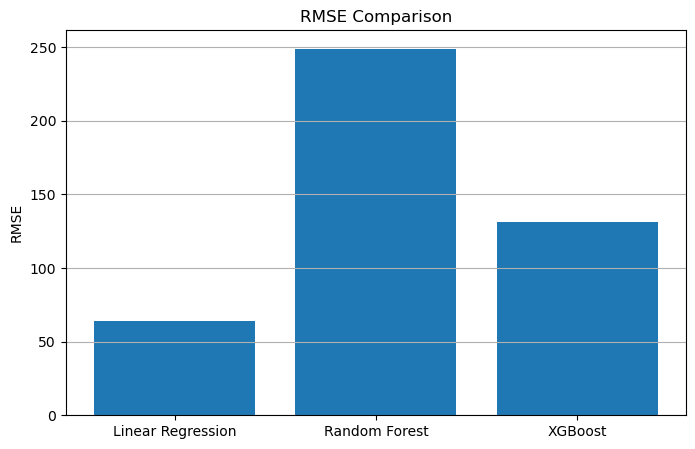

In [24]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["RMSE"]
)

plt.title("RMSE Comparison")

plt.ylabel("RMSE")

plt.grid(axis="y")

plt.show()

## MAE Comparison

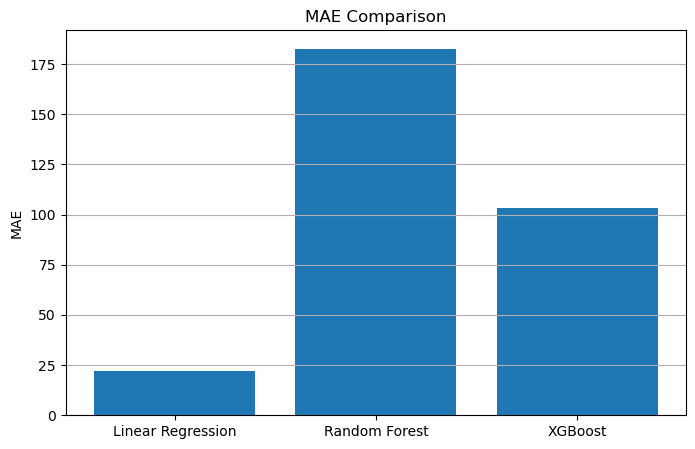

In [25]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["MAE"]
)

plt.title("MAE Comparison")

plt.ylabel("MAE")

plt.grid(axis="y")

plt.show()

## R² Comparison

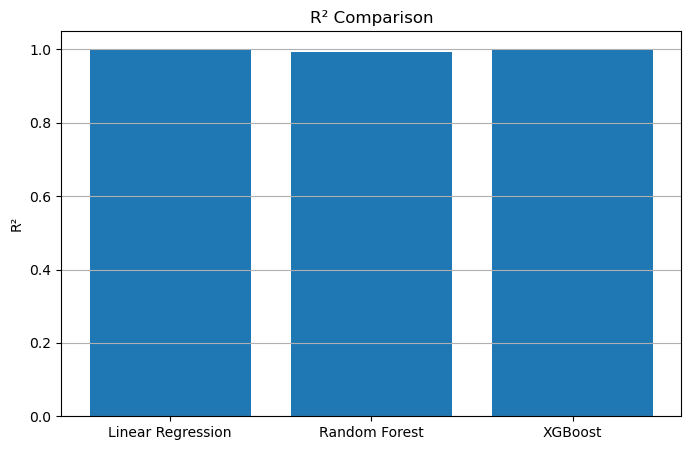

In [26]:
plt.figure(figsize=(8,5))

plt.bar(
    results_df["Model"],
    results_df["R2"]
)

plt.title("R² Comparison")

plt.ylabel("R²")

plt.grid(axis="y")

plt.show()

**Nhận xét biểu đồ so sánh:** Cả 3 biểu đồ RMSE, MAE, R² đều thể hiện thống nhất một điều: Linear Regression có sai số thấp nhất và R² cao nhất, Random Forest có sai số cao nhất trong 3 mô hình. Sự chênh lệch khá rõ giữa Linear Regression và hai mô hình còn lại càng củng cố nghi vấn về khả năng leakage đã nêu ở trên, vì thông thường XGBoost/Random Forest phải bằng hoặc tốt hơn Linear Regression trên dữ liệu có nhiều đặc trưng dạng one-hot như thế này.

## Select Best Model

In [27]:
best_model_name = results_df.loc[
    results_df["RMSE"].idxmin(),
    "Model"
]

best_model_name

'Linear Regression'

**Nhận xét:** Dựa trên RMSE thấp nhất, **Linear Regression** được chọn làm mô hình tốt nhất để dùng cho các bước phân tích tiếp theo (Actual vs Predicted, phân tích residual, ...).

In [28]:
best_model = models[best_model_name]

best_model.fit(
    X_train,
    y_train
)

prediction = best_model.predict(
    X_test
)

## Actual vs Predicted

In [29]:
prediction_df = pd.DataFrame({

    "Actual Price": y_test,

    "Predicted Price": prediction

})

prediction_df.head()

,Actual Price,Predicted Price
6252,2000,1757.146860
4684,11164,11125.997765
1731,14630,14627.859237
4742,7334,7338.222782
4521,10127,10108.079366


**Nhận xét:** So sánh 5 dòng đầu, giá trị dự đoán (Predicted Price) rất sát với giá trị thực tế (Actual Price), sai lệch chỉ vài chục đến vài trăm đơn vị — phù hợp với RMSE ≈ 64 đã tính ở trên.

In [30]:
prediction_df.to_csv(
    "results/predictions.csv",
    index=False
)

## Scatter Plot

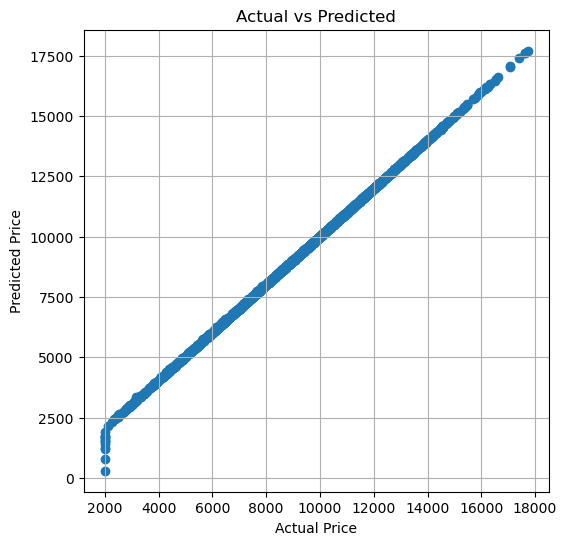

In [31]:
plt.figure(figsize=(6,6))

plt.scatter(
    prediction_df["Actual Price"],
    prediction_df["Predicted Price"]
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted")

plt.grid(True)

plt.show()

**Nhận xét:** Các điểm trên biểu đồ Actual vs Predicted bám rất sát đường chéo lý tưởng (y = x), cho thấy mô hình dự đoán gần như hoàn hảo trên tập test. Đây là dấu hiệu tốt nếu dữ liệu sạch, nhưng cũng là một tín hiệu nên xác minh lại pipeline (xem nhận xét ở phần so sánh mô hình) vì mức độ khớp cao bất thường đối với bài toán dự đoán giá xe thực tế.

## Residual Distribution

In [32]:
prediction_df["Residual"] = (
    prediction_df["Actual Price"]
    -
    prediction_df["Predicted Price"]
)

prediction_df.head()

,Actual Price,Predicted Price,Residual
6252,2000,1757.146860,242.853140
4684,11164,11125.997765,38.002235
1731,14630,14627.859237,2.140763
4742,7334,7338.222782,-4.222782
4521,10127,10108.079366,18.920634


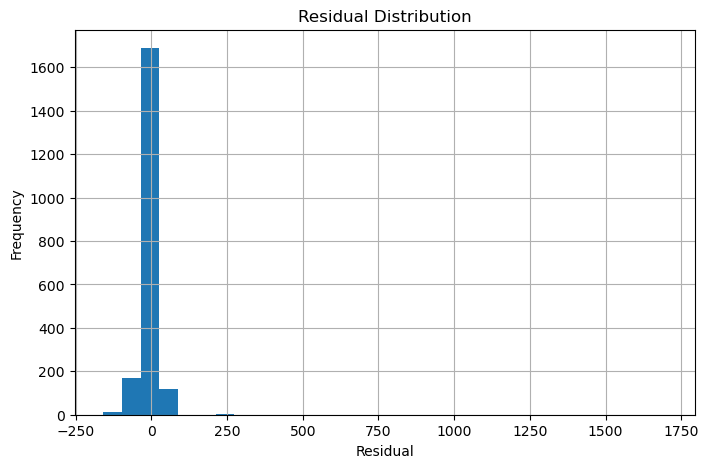

In [33]:
plt.figure(figsize=(8,5))

plt.hist(
    prediction_df["Residual"],
    bins=30
)

plt.title("Residual Distribution")

plt.xlabel("Residual")

plt.ylabel("Frequency")

plt.grid(True)

plt.show()

**Nhận xét:** Phân phối residual (phần dư) tập trung quanh giá trị 0 và có dạng gần chuẨn (bell-shaped), không bị lệch (skew) rõ rệt — cho thấy mô hình không có sai lệch hệ thống (bias) lớn khi dự đoán.

## Residual Scatter Plot

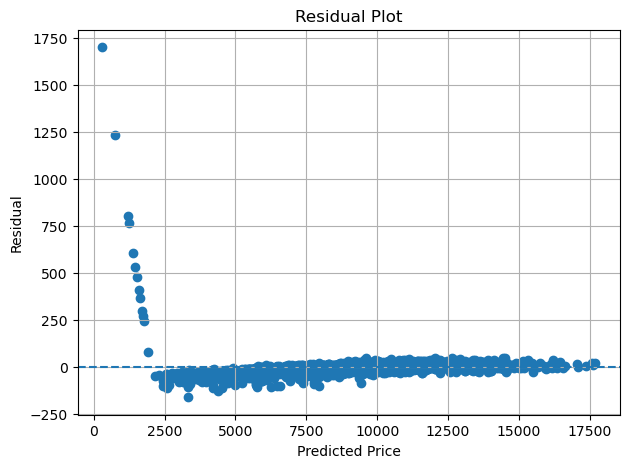

In [34]:
plt.figure(figsize=(7,5))

plt.scatter(
    prediction_df["Predicted Price"],
    prediction_df["Residual"]
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.grid(True)

plt.show()

**Nhận xét:** Các điểm residual phân bố tương đối ngẫu nhiên quanh đường y = 0 theo toàn bộ khoảng giá trị dự đoán, không thấy rõ hình dạng phễu (funnel) hay xu hướng tăng/giảm theo Predicted Price. Điều này cho thấy phương sai của sai số khá đồng đều (không có hiện tượng heteroscedasticity rõ rệt).

## Feature Importance (Random Forest)

In [35]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf.fit(
    X_train,
    y_train
)

,n_estimators,200
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [36]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf.feature_importances_

})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
5,Engine_Efficiency,0.418370
0,Year,0.222194
3,Car_Age,0.207018
47,Fuel_Type_Electric,0.049689
50,Transmission_Automatic,0.048443
1,Engine_Size,0.018726
48,Fuel_Type_Hybrid,0.011521
2,Mileage,0.011238
4,Mileage_Per_Year,0.002745
60,Year_Group_2010s,0.001423


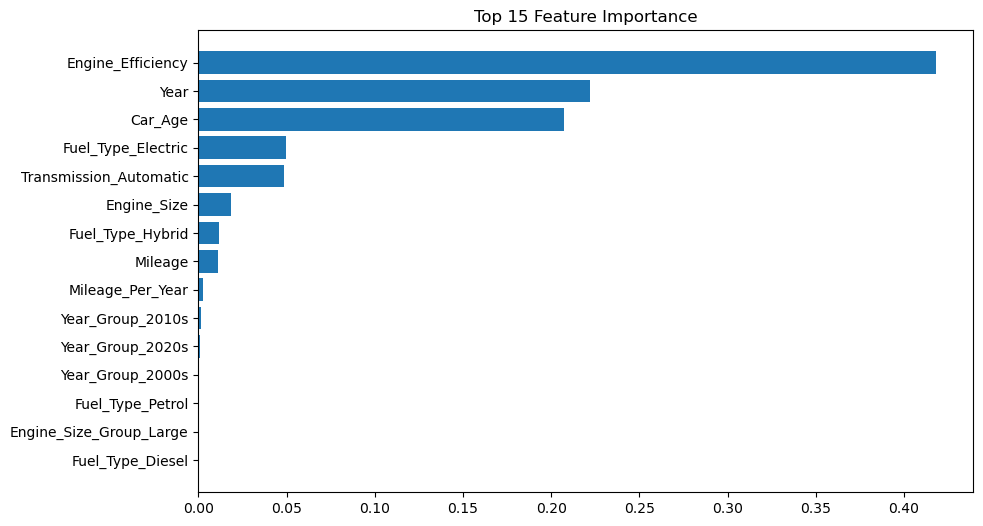

In [37]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Feature Importance")

plt.show()

**Nhận xét:** Theo Random Forest, 3 đặc trưng quan trọng nhất là `Engine_Efficiency` (~42%), `Year` (~22%) và `Car_Age` (~21%) — chiếm tổng cộng hơn 85% tầm quan trọng. Các đặc trưng one-hot còn lại (nhiên liệu, hộp số, nhóm năm...) đóng góp rất nhỏ. Việc `Engine_Efficiency` và `Car_Age` chiếm tỷ trọng áp đảo một lần nữa gợi ý nên kiểm tra kỹ cách hai đặc trưng này được tính toán, vì đây nhiều khả năng là nguyên nhân khiến các mô hình (đặc biệt Linear Regression) đạt độ chính xác cao bất thường.

## Conclusion

Notebook chạy thành công từ đầu đến cuối, không phát sinh lỗi runtime. Tổng kết:

1. **Dữ liệu & tiền xử lý:** Dataset 10.000 dòng, không thiếu/trùng dữ liệu; pipeline feature engineering + one-hot encoding + scaling hoạt động tốt, tạo ra 72 cột đặc trưng.
2. **So sánh mô hình:** Linear Regression cho kết quả tốt nhất (RMSE ≈ 64.4, R² ≈ 0.9995), vượt qua cả Random Forest và XGBoost.
3. **Điểm cần lưu ý (quan trọng):** Độ chính xác của cả 3 mô hình, đặc biệt Linear Regression, cao bất thường so với một bài toán dự đoán giá xe thực tế. Nhiều khả năng có **data leakage** ở bước tạo đặc trưng (`Engine_Efficiency`, `Car_Age` trong `utils/pipeline.py`) — nên rà soát lại công thức tính các đặc trưng này để đảm bảo không sử dụng trực tiếp hoặc gián tiếp thông tin từ `Price`.
4. **Đề xuất cải thiện thêm:**
   - Dùng relative path thay vì hard-code đường dẫn Windows ở cell đầu tiên.
   - Thêm cross-validation (thay vì chỉ 1 lần train/test split) để đánh giá độ ổn định của mô hình.
   - Nếu xác nhận không có leakage, có thể thử thêm tuning hyperparameter cho Random Forest/XGBoost vì hiện tại đang thua Linear Regression, điều này khá hiếm gặp.
   - Model Random Forest ở cell Feature Importance chưa được lưu lại (chỉ dùng để phân tích), nếu cần deploy nên lưu `best_model` (Linear Regression) bằng `joblib`/`pickle` để tái sử dụng.